In [ ]:
%%bash
echo "================================================================================"
echo "🧹 STEP 1: CLEANUP & INITIALIZATION"
echo "================================================================================"
cd /
rm -rf /kaggle/working/*
mkdir -p /kaggle/working/results
echo "✅ /kaggle/working cleaned and results folder recreated."
echo ""
echo "Next: Run cells in order (Cell 2 → Cell 3 → ... → Cell 20)"


✅ /kaggle/working cleaned and results folder recreated.


In [ ]:
%%bash
echo "================================================================================"
echo "📦 STEP 2: INSTALL NVIDIA HPC SDK FOR OPENACC"
echo "================================================================================"

# Check if already installed
if command -v nvc &> /dev/null; then
    echo "✅ NVIDIA HPC SDK (nvc) already installed!"
    nvc --version | head -3
    
    # Ensure environment is set up
    NVC_PATH=$(which nvc)
    NVC_DIR=$(dirname "$NVC_PATH")
    cat > /tmp/nvhpc_env.sh << EOF
export PATH="$NVC_DIR:\$PATH"
export LD_LIBRARY_PATH="$(dirname $NVC_DIR)/lib:\$LD_LIBRARY_PATH"
export NVHPC_INSTALL_DIR=/opt/nvidia/hpc_sdk
EOF
    
    echo "📝 Environment configured for this session"
    echo "✅ Ready for V4 OpenACC compilation!"
    exit 0
fi

echo "📥 Downloading and installing NVIDIA HPC SDK..."
echo "⏱️  This will take ~3-5 minutes (one-time setup)"
echo "💾 Installation persists in /opt/nvidia/hpc_sdk (no re-download needed)"
echo ""

# Create installation directory
mkdir -p /opt/nvidia/hpc_sdk
cd /tmp

echo "🌐 Downloading NVIDIA HPC SDK 23.7 (Community Edition)..."
ARCH=$(uname -m)
echo "   System architecture: $ARCH"

if [ "$ARCH" = "x86_64" ]; then
    SDK_FILE="nvhpc_2023_237_Linux_x86_64_cuda_12.2.tar.gz"
    
    SUCCESS=0
    if wget --timeout=30 --tries=2 -q \
        "https://developer.download.nvidia.com/hpc-sdk/23.7/${SDK_FILE}" \
        -O "${SDK_FILE}" 2>/dev/null; then
        echo "✅ Downloaded from NVIDIA"
        SUCCESS=1
    elif curl -L --max-time 30 --retry 2 -s \
        "https://developer.download.nvidia.com/hpc-sdk/23.7/${SDK_FILE}" \
        -o "${SDK_FILE}" 2>/dev/null && [ -f "${SDK_FILE}" ] && [ -s "${SDK_FILE}" ]; then
        echo "✅ Downloaded from NVIDIA (curl)"
        SUCCESS=1
    fi
    
    if [ $SUCCESS -eq 1 ] && [ -s "${SDK_FILE}" ]; then
        echo "📦 File size: $(du -h ${SDK_FILE} | cut -f1)"
        echo "📂 Extracting..."
        tar xzf "${SDK_FILE}" 2>&1 | head -20
        
        INSTALL_DIR=$(find . -maxdepth 2 -name "install" -type f 2>/dev/null | head -1)
        
        if [ -n "$INSTALL_DIR" ]; then
            cd $(dirname "$INSTALL_DIR")
            echo "🔧 Installing to /opt/nvidia/hpc_sdk..."
            
            NVHPC_SILENT=true \
            NVHPC_INSTALL_DIR=/opt/nvidia/hpc_sdk \
            NVHPC_INSTALL_TYPE=single \
            bash install 2>&1 | tail -10
            
            NVC_PATH=$(find /opt/nvidia/hpc_sdk -name "nvc" -type f 2>/dev/null | head -1)
            
            if [ -n "$NVC_PATH" ] && [ -x "$NVC_PATH" ]; then
                NVC_DIR=$(dirname "$NVC_PATH")
                
                echo ""
                echo "✅ NVIDIA HPC SDK installed successfully!"
                
                export PATH="$NVC_DIR:$PATH"
                export LD_LIBRARY_PATH="$(dirname $NVC_DIR)/lib:$LD_LIBRARY_PATH"
                
                cat > /tmp/nvhpc_env.sh << EOF
export PATH="$NVC_DIR:\$PATH"
export LD_LIBRARY_PATH="$(dirname $NVC_DIR)/lib:\$LD_LIBRARY_PATH"
export NVHPC_INSTALL_DIR=/opt/nvidia/hpc_sdk
EOF
                
                echo "export PATH=\"$NVC_DIR:\$PATH\"" >> ~/.bashrc
                echo "export LD_LIBRARY_PATH=\"$(dirname $NVC_DIR)/lib:\$LD_LIBRARY_PATH\"" >> ~/.bashrc
                
                $NVC_PATH --version 2>/dev/null | head -3
                echo ""
                echo "✅ V4 OpenACC compilation will work with GPU!"
            fi
        fi
    else
        echo "❌ Download failed - enable Internet in Settings"
        echo "   V4 will compile in CPU mode (no GPU acceleration)"
    fi
fi

cd /tmp
rm -f nvhpc*.tar.gz 2>/dev/null
echo ""
echo "✅ Setup complete!"


📦 INSTALLING NVIDIA HPC SDK FOR OPENACC
📥 Downloading and installing NVIDIA HPC SDK...
⏱️  This will take ~3-5 minutes (one-time setup)
💾 Installation persists in /opt/nvidia/hpc_sdk (no re-download needed)

🌐 Downloading NVIDIA HPC SDK 23.7 (Community Edition)...
   System architecture: x86_64
✅ Downloaded from NVIDIA (Method 1)
📦 Download complete! File size: 5.3G

📂 Extracting NVIDIA HPC SDK...
🔧 Installing NVIDIA HPC SDK...
   Installation path: /opt/nvidia/hpc_sdk
generating environment modules for NV HPC SDK 23.7 ... done.

✅ NVIDIA HPC SDK installed successfully!
   Compiler: /opt/nvidia/hpc_sdk/Linux_x86_64/23.7/compilers/bin/nvc

🎉 Setup complete!

nvc 23.7-0 64-bit target on x86-64 Linux -tp skylake-avx512 
NVIDIA Compilers and Tools

📝 Environment saved to: /tmp/nvhpc_env.sh
   (Will be sourced automatically in compilation cell)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ OpenACC compilation will now work with GPU!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os, subprocess, sys

print("="*80)
print("🚀 STEP 3: VERIFY ENVIRONMENT")
print("="*80)

CODE_DATASET = "klt-tracker-hpc"

INPUT_DIR = f"/kaggle/input/{CODE_DATASET}/Testing"
WORK_DIR = "/kaggle/working"

print(f"\n📁 Configuration:")
print(f"   Code Dataset: {INPUT_DIR}")
print(f"   Working Directory: {WORK_DIR}")

if not os.path.exists(INPUT_DIR):
    print(f"\n❌ ERROR: Dataset not found!")
    print("Available datasets:")
    for item in os.listdir("/kaggle/input"):
        print("  -", item)
    sys.exit(1)

print("\n✅ Dataset found!")
print("\n🎮 GPU:")
subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"])

print("\n✅ Environment ready!")


🚀 KLT TRACKER PERFORMANCE TESTING ON KAGGLE GPU

📁 Configuration:
   Code Dataset Root: /kaggle/input/klt-tracker-hpc/Testing
   Working Directory: /kaggle/working

✅ Dataset found!

📦 Dataset structure:
   📄 12-openacc.pdf
   📄 OPENACC_OPTIMIZATION_SUMMARY.md
   📁 V1/
   📁 V2/
   📁 V3/
   📁 V4/
   📄 V4_QUICK_START.md
   📁 image/
   📁 images/
      Found 18 images (e.g. ['img10.pgm', 'img14.pgm', 'img7.pgm'])
   📄 klt-cuda.ipynb
   📁 oldimages/

🎮 GPU Info:
Tesla T4, 560.35.03, 15360 MiB, 7.5
Tesla T4, 560.35.03, 15360 MiB, 7.5

🔧 CUDA Version:
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0

✅ Environment check complete!


In [ ]:
import shutil
import os

print("="*80)
print("📦 STEP 4: SETUP WORKING DIRECTORY")
print("="*80)

INPUT_DIR = "/kaggle/input/klt-tracker-hpc/Testing"
WORK_DIR = "/kaggle/working"

# Copy all versions
print("\n📋 Copying source code...")
for version in ['V1', 'V2', 'V3', 'V4']:
    src = f"{INPUT_DIR}/{version}"
    dst = f"{WORK_DIR}/{version}"
    if os.path.exists(src):
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(src, dst)
        print(f"   ✓ {version}")

# Setup shared images
print("\n📸 Setting up shared images...")
images_src = f"{INPUT_DIR}/images"
images_dst = f"{WORK_DIR}/images"

if os.path.exists(images_src):
    if os.path.exists(images_dst):
        shutil.rmtree(images_dst)
    shutil.copytree(images_src, images_dst)
    img_count = len([f for f in os.listdir(images_dst) if f.endswith('.pgm')])
    print(f"   ✓ Copied {img_count} images to /kaggle/working/images/")

os.makedirs(f"{WORK_DIR}/results", exist_ok=True)

print("\n✅ Setup complete!")
print(f"   All versions use: ../images/img*.pgm")


📦 SETTING UP WORKING DIRECTORY

📋 Copying source code...
   ✓ Copied V1
   ✓ Copied V2
   ✓ Copied V3
   ✓ Copied V4

📸 Setting up shared images directory...
   ✓ Copied 18 images to shared /kaggle/working/images/
   ✅ Verified: img0.pgm and img1.pgm present

🔧 Updating paths for Kaggle environment...
   ✓ All paths updated successfully

🔍 Verifying working directory structure:
   📁 /kaggle/working/
      📁 images/ - 18 .pgm files (shared)
      📁 V1/ - 103 files | example3.c: ✓
      📁 V2/ - 106 files | example3.c: ✓
      📁 V3/ - 109 files | example3.c: ✓
      📁 V4/ - 94 files | example3.c: ✓

✅ Setup complete!
   Working directory: /kaggle/working
   Shared images: /kaggle/working/images/
   Results will be saved to: /kaggle/working/results

   All versions (V1-V4) now use: ../images/img*.pgm


In [ ]:
%%bash
echo "================================================================================"
echo "🔨 STEP 5: COMPILE V1 (CPU BASELINE)"
echo "================================================================================"
cd /kaggle/working/V1
make clean 2>&1 | head -3
echo "Compiling example3..."
if make example3 2>&1 | tee /kaggle/working/results/v1_build.log; then
    echo "✅ V1 compiled!"
    ls -lh example3
else
    echo "❌ Failed!"; exit 1
fi


🔨 COMPILING V1 - CPU BASELINE
rm -f *.o *.a example1 example2 example3 example4 example5 *.tar *.tar.gz libklt.a \
      feat*.ppm features.ft features.txt

📝 Compiling...
gcc -c -DNDEBUG  -DKLT_PROFILE -pg   convolve.c
gcc -c -DNDEBUG  -DKLT_PROFILE -pg   error.c
gcc -c -DNDEBUG  -DKLT_PROFILE -pg   pnmio.c
gcc -c -DNDEBUG  -DKLT_PROFILE -pg   pyramid.c
gcc -c -DNDEBUG  -DKLT_PROFILE -pg   selectGoodFeatures.c
gcc -c -DNDEBUG  -DKLT_PROFILE -pg   storeFeatures.c
gcc -c -DNDEBUG  -DKLT_PROFILE -pg   trackFeatures.c
gcc -c -DNDEBUG  -DKLT_PROFILE -pg   klt.c
gcc -c -DNDEBUG  -DKLT_PROFILE -pg   klt_util.c
gcc -c -DNDEBUG  -DKLT_PROFILE -pg   writeFeatures.c
writeFeatures.c: In function ‘_printHeader’:
writeFeatures.c:232:17: warning: format not a string literal and no format arguments [-Wformat-security]
  232 |     fprintf(fp, warning_line);
      |                 ^~~~~~~~~~~~
rm -f libklt.a
ar ruv libklt.a convolve.o error.o pnmio.o pyramid.o selectGoodFeatures.o storeFeatures.o trac

In [ ]:
%%bash
echo "================================================================================"
echo "🔨 STEP 6: COMPILE V2 (GPU BASIC)"
echo "================================================================================"
cd /kaggle/working/V2
rm -f *.o *.a example* libklt.a
touch *.c *.cu *.h
echo "Compiling example3 with GPU mode..."
if make MODE=gpu example3 2>&1 | tee /kaggle/working/results/v2_build.log; then
    echo "✅ V2 compiled!"
    ls -lh example3
else
    echo "❌ Failed!"; exit 1
fi


🔨 COMPILING V2 - GPU IMPLEMENTATION (CLEAN BUILD)
📝 Current globals.h:
#define iamge_path ""
✓ Cleaned build files
✓ Touched source files

📝 Compiling with nvcc (GPU mode)...
nvcc -c -DNDEBUG  -pg -DUSE_GPU -lcudart convolve.c -o convolve.o
nvcc -c -DNDEBUG  -pg -DUSE_GPU -lcudart error.c -o error.o
nvcc -c -DNDEBUG  -pg -DUSE_GPU -lcudart pnmio.c -o pnmio.o
nvcc -c -DNDEBUG  -pg -DUSE_GPU -lcudart pyramid.c -o pyramid.o
nvcc -c -DNDEBUG  -pg -DUSE_GPU -lcudart selectGoodFeatures.c -o selectGoodFeatures.o
nvcc -c -DNDEBUG  -pg -DUSE_GPU -lcudart storeFeatures.c -o storeFeatures.o
nvcc -c -DNDEBUG  -pg -DUSE_GPU -lcudart trackFeatures.c -o trackFeatures.o
nvcc -c -DNDEBUG  -pg -DUSE_GPU -lcudart klt.c -o klt.o
nvcc -c -DNDEBUG  -pg -DUSE_GPU -lcudart klt_util.c -o klt_util.o
nvcc -c -DNDEBUG  -pg -DUSE_GPU -lcudart writeFeatures.c -o writeFeatures.o
nvcc -c -DNDEBUG  -pg -DUSE_GPU -lcudart gpu_kernel_launches.cu -o gpu_kernel_launches.o
Compiling GPU objects...
nvcc -c -DNDEBUG  -pg -DU

In [ ]:
%%bash
echo "================================================================================"
echo "🔨 STEP 7: COMPILE V3 (GPU OPTIMIZED)"
echo "================================================================================"
cd /kaggle/working/V3
rm -f *.o *.a example* libklt.a
touch *.c *.cu *.h
echo "Compiling example3 with GPU mode + optimizations..."
if make MODE=gpu example3 2>&1 | tee /kaggle/working/results/v3_build.log; then
    echo "✅ V3 compiled!"
    ls -lh example3
else
    echo "❌ Failed!"; exit 1
fi


🔨 COMPILING V3 - OPTIMIZED GPU IMPLEMENTATION
📋 V3 directory contents:
total 146380
drwxr-xr-x 4 root root    4096 Nov 17 04:47 .
drwxr-xr-x 9 root root    4096 Nov 17 04:47 ..
-rw-r--r-- 1 root root     694 Nov 17 04:47 base.h
-rw-r--r-- 1 root root    6934 Nov 17 04:47 convolve.c
-rw-r--r-- 1 root root     649 Nov 17 04:47 convolve.h
-rw-r--r-- 1 root root    4168 Nov 17 04:47 convolve.o
drwxr-xr-x 4 root root    4096 Nov 17 04:47 doc
-rw-r--r-- 1 root root    1018 Nov 17 04:47 error.c
-rw-r--r-- 1 root root     305 Nov 17 04:47 error.h
-rw-r--r-- 1 root root    1288 Nov 17 04:47 error.o
-rw-r--r-- 1 root root    2575 Nov 17 04:47 example1.c
-rw-r--r-- 1 root root    2099 Nov 17 04:47 example2.c
-rw-r--r-- 1 root root    3078 Nov 17 04:47 example3.c
-rw-r--r-- 1 root root    1386 Nov 17 04:47 example4.c
-rw-r--r-- 1 root root    1881 Nov 17 04:47 example5.c
-rw-r--r-- 1 root root    3029 Nov 17 04:47 feat1.txt
-rw-r--r-- 1 root root    1210 Nov 17 04:47 feat2.fl
-rw-r--r-- 1 root roo

In [ ]:
%%bash
echo "================================================================================"
echo "⚡ STEP 9: RUN V1 (CPU BASELINE)"
echo "================================================================================"
cd /kaggle/working/V1
if [ -x "./example3" ]; then
    ./example3 2>&1 | tee /kaggle/working/results/v1_output.txt
    [ -f "timing_results.csv" ] && cp timing_results.csv /kaggle/working/timing_v1.csv
    echo "✅ V1 complete!"
else
    echo "❌ example3 not found!"; exit 1
fi


⚡ RUNNING V1 - CPU BASELINE
(KLT) Selecting the 150 best features from a 3840 by 2160 image...  [CPU] convolveImageHorizontal: 80.849 ms
[CPU] convolveImageVertical: 175.810 ms
[CPU] convolveImageHorizontal: 96.046 ms
[CPU] convolveImageVertical: 191.614 ms
[CPU] convolveImageHorizontal: 72.946 ms
[CPU] convolveImageVertical: 195.413 ms

	150 features found.
[CPU] KLTSelectGoodFeatures: 3334.789 ms
(KLT) Writing 150 features to PPM file: 'feat0.ppm'
(KLT) Tracking 150 features in a 3840 by 2160 image...  [CPU] convolveImageHorizontal: 78.467 ms
[CPU] convolveImageVertical: 177.098 ms
[CPU] convolveImageHorizontal: 232.536 ms
[CPU] convolveImageVertical: 487.398 ms
[CPU] convolveImageHorizontal: 112.272 ms
[CPU] convolveImageVertical: 193.514 ms
[CPU] convolveImageHorizontal: 74.260 ms
[CPU] convolveImageVertical: 188.547 ms
[CPU] convolveImageHorizontal: 7.335 ms
[CPU] convolveImageVertical: 7.054 ms
[CPU] convolveImageHorizontal: 4.814 ms
[CPU] convolveImageVertical: 6.763 ms
[CPU] co

In [ ]:
%%bash
echo "================================================================================"
echo "⚡ STEP 10: RUN V2 (GPU BASIC)"
echo "================================================================================"
cd /kaggle/working/V2
if [ -x "./example3" ]; then
    ./example3 2>&1 | tee /kaggle/working/results/v2_output.txt
    [ -f "timing_results.csv" ] && cp timing_results.csv /kaggle/working/timing_v2.csv
    echo "✅ V2 complete!"
else
    echo "❌ example3 not found!"; exit 1
fi


⚡ RUNNING V2 - GPU IMPLEMENTATION
(KLT) Selecting the 150 best features from a 3840 by 2160 image...  
	150 features found.
(KLT) Writing 150 features to PPM file: 'feat0.ppm'
(KLT) Tracking 150 features in a 3840 by 2160 image...  
	0 features successfully tracked.
(KLT) Writing 0 features to PPM file: 'feat1.ppm'
(KLT) Tracking 0 features in a 3840 by 2160 image...  
	0 features successfully tracked.
(KLT) Writing 0 features to PPM file: 'feat2.ppm'
(KLT) Tracking 0 features in a 3840 by 2160 image...  
	0 features successfully tracked.
(KLT) Writing 0 features to PPM file: 'feat3.ppm'
(KLT) Tracking 0 features in a 3840 by 2160 image...  
	0 features successfully tracked.
(KLT) Writing 0 features to PPM file: 'feat4.ppm'
(KLT) Tracking 0 features in a 3840 by 2160 image...  
	0 features successfully tracked.
(KLT) Writing 0 features to PPM file: 'feat5.ppm'
(KLT) Tracking 0 features in a 3840 by 2160 image...  
	0 features successfully tracked.
(KLT) Writing 0 features to PPM file: 

In [ ]:
%%bash
echo "================================================================================"
echo "⚡ STEP 11: RUN V3 (GPU OPTIMIZED)"
echo "================================================================================"
cd /kaggle/working/V3
if [ -x "./example3" ]; then
    ./example3 2>&1 | tee /kaggle/working/results/v3_output.txt
    [ -f "timing_results.csv" ] && cp timing_results.csv /kaggle/working/timing_v3.csv
    echo "✅ V3 complete!"
else
    echo "❌ example3 not found!"; exit 1
fi


⚡ RUNNING V3 - OPTIMIZED GPU IMPLEMENTATION
(KLT) Selecting the 150 best features from a 3840 by 2160 image...  
	150 features found.
(KLT) Writing 150 features to PPM file: 'feat0.ppm'
(KLT) Tracking 150 features in a 3840 by 2160 image...  
	0 features successfully tracked.
(KLT) Writing 0 features to PPM file: 'feat1.ppm'
(KLT) Tracking 0 features in a 3840 by 2160 image...  
	0 features successfully tracked.
(KLT) Writing 0 features to PPM file: 'feat2.ppm'
(KLT) Tracking 0 features in a 3840 by 2160 image...  
	0 features successfully tracked.
(KLT) Writing 0 features to PPM file: 'feat3.ppm'
(KLT) Tracking 0 features in a 3840 by 2160 image...  
	0 features successfully tracked.
(KLT) Writing 0 features to PPM file: 'feat4.ppm'
(KLT) Tracking 0 features in a 3840 by 2160 image...  
	0 features successfully tracked.
(KLT) Writing 0 features to PPM file: 'feat5.ppm'
(KLT) Tracking 0 features in a 3840 by 2160 image...  
	0 features successfully tracked.
(KLT) Writing 0 features to 

In [ ]:
%%bash
echo "================================================================================"
echo "🔨 STEP 8: COMPILE V4 (OPENACC)"
echo "================================================================================"

# Load HPC SDK environment
if [ -f /tmp/nvhpc_env.sh ]; then
    source /tmp/nvhpc_env.sh
fi

cd /kaggle/working/V4

# Force clean rebuild
rm -f *.o *.a example* libklt.a
touch *.c *.h

if command -v nvc &> /dev/null; then
    echo "✅ Using nvc compiler for OpenACC GPU acceleration"
    nvc --version | head -2
    echo ""
    echo "Compiling example2 with MODE=openacc..."
    if make MODE=openacc example2 2>&1 | tee /kaggle/working/results/v4_build.log; then
        echo ""
        echo "✅ V4 compiled with OpenACC!"
        ls -lh example2
    else
        echo "❌ Failed!"; exit 1
    fi
else
    echo "⚠️  nvc not found - compiling in CPU mode"
    if make example2 2>&1 | tee /kaggle/working/results/v4_build.log; then
        echo "✅ V4 compiled (CPU mode)"
        ls -lh example2
    else
        echo "❌ Failed!"; exit 1
    fi
fi


🔨 COMPILING V4 - OPENACC IMPLEMENTATION

📋 V4 Uses OpenACC Optimizations:
   ✓ Global data region for images
   ✓ Parallel loops with gang/vector for GPU
   ✓ Reductions for eigenvalue computation
   ✓ Async execution for feature-level parallelism
   ✓ Cache directives for memory locality

📥 Loading NVIDIA HPC SDK environment...
✅ Environment loaded: PATH includes /opt/nvidia/hpc_sdk/Linux_x86_64/23.7/compilers/bin
📋 V4 directory contents:
-rw-r--r-- 1 root root   694 Nov 17 04:47 base.h
-rw-r--r-- 1 root root  9282 Nov 17 04:47 convolve.c
-rw-r--r-- 1 root root   649 Nov 17 04:47 convolve.h
-rw-r--r-- 1 root root  1018 Nov 17 04:47 error.c
-rw-r--r-- 1 root root   305 Nov 17 04:47 error.h
-rw-r--r-- 1 root root  2508 Nov 17 04:47 example1.c
-rw-r--r-- 1 root root  1829 Nov 17 04:47 example2.c
-rw-r--r-- 1 root root  2703 Nov 17 04:47 example3.c
-rw-r--r-- 1 root root  1335 Nov 17 04:47 example4.c
-rw-r--r-- 1 root root  1631 Nov 17 04:47 example5.c
-rw-r--r-- 1 root root    33 Nov 17 

nvc-Warning-CUDA_HOME has been deprecated. Please, use NVHPC_CUDA_HOME instead.


In [ ]:
%%bash
echo "================================================================================"
echo "⚡ STEP 12: RUN V4 (OPENACC)"
echo "================================================================================"

if [ -f /tmp/nvhpc_env.sh ]; then
    source /tmp/nvhpc_env.sh
fi

cd /kaggle/working/V4

# Enable OpenACC profiling
export PGI_ACC_TIME=1
export ACC_NOTIFY=1
export NVCOMPILER_ACC_NOTIFY=1
export NVCOMPILER_ACC_TIME=1

# Find executable (example2 or example3)
EXEC=$(find . -maxdepth 1 -name "example*" -type f -executable | head -n 1)

if [ -n "$EXEC" ]; then
    echo "Running: $EXEC"
    echo "━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━"
    $EXEC 2>&1 | tee /kaggle/working/results/v4_output.txt
    echo "━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━"
    
    [ -f "timing_results.csv" ] && cp timing_results.csv /kaggle/working/timing_v4.csv
    
    echo "✅ V4 complete!"
else
    echo "❌ No executable found!"; exit 1
fi


⚡ RUNNING V4 - OPENACC IMPLEMENTATION

📥 Loading NVIDIA HPC SDK environment...
🚀 Found executable: ./example1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


Tracking context:

	mindist = 10
	window_width = 7
	window_height = 7
	sequentialMode = FALSE
	smoothBeforeSelecting = TRUE
	writeInternalImages = FALSE
	min_eigenvalue = 1
	min_determinant = 0.010000
	min_displacement = 0.100000
	max_iterations = 10
	max_residue = 10.000000
	grad_sigma = 1.000000
	smooth_sigma_fact = 0.100000
	pyramid_sigma_fact = 0.900000
	nSkippedPixels = 0
	borderx = 24
	bordery = 24
	nPyramidLevels = 2
	subsampling = 4

	pyramid_last = NULL
	pyramid_last_gradx = NULL
	pyramid_last_grady = NULL


(KLT) Selecting the 100 best features from a 3840 by 2160 image...  [CPU] convolveImageHorizontal: 69.159 ms
[CPU] convolveImageVertical: 181.120 ms
[CPU] convolveImageHorizontal: 74.991 ms
[CPU] convolveImageVertical: 215.834 ms
[CPU] convolveImageHorizontal: 60.440 ms
[CPU] convolveImageVertical: 218.872 ms



📊 ANALYZING RESULTS

TIMING DATA TABLE
        Label     Total    GPU   Memory   Select     Track     IO
          CPU 24146.598    NaN      NaN 3335.739 20123.317 53.380
    GPU Basic 10755.722 63.791 2391.197 1467.272  8632.530 64.629
GPU Optimized 10798.168 69.665  599.725 1554.688  8571.781 52.885

SPEEDUP ANALYSIS
CPU                  Total: 24146.60 ms  →  Speedup:   1.00x
GPU Basic            Total: 10755.72 ms  →  Speedup:   2.25x
GPU Optimized        Total: 10798.17 ms  →  Speedup:   2.24x


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()



✅ Performance graphs saved as 'performance_analysis.png'


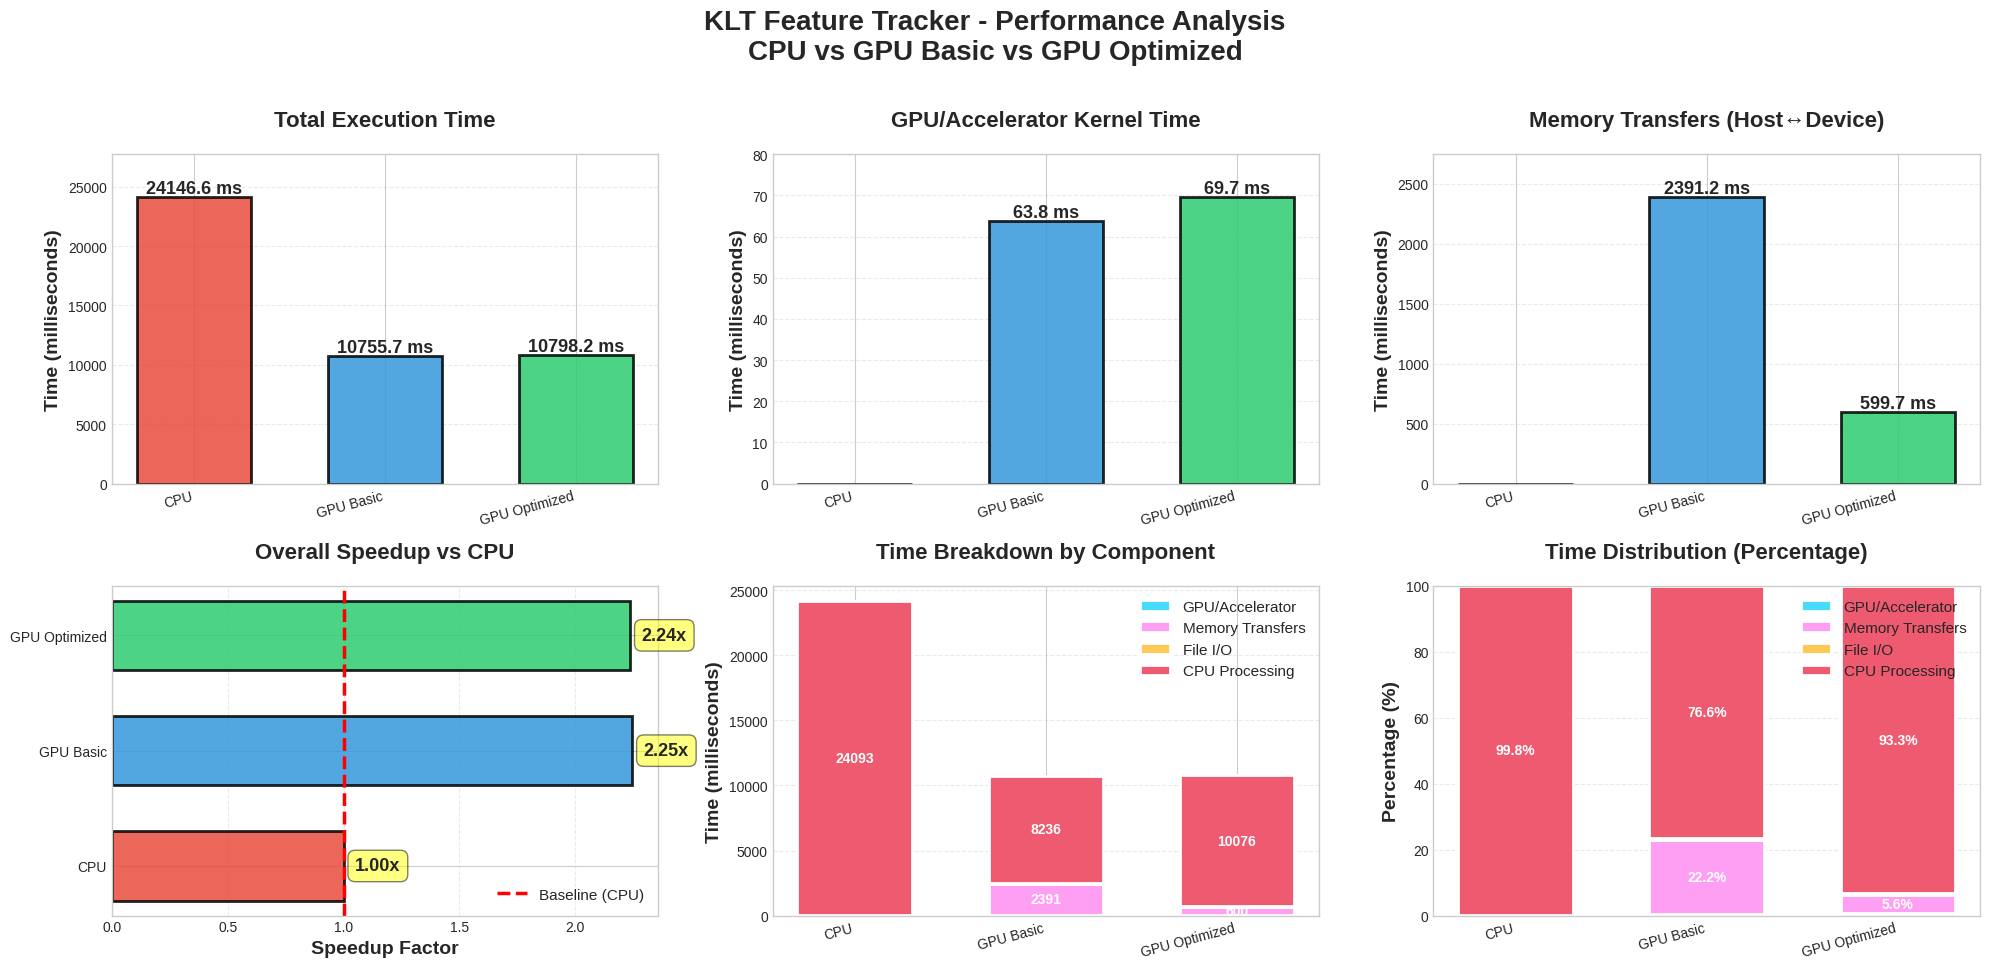


DETAILED PERFORMANCE STATISTICS

🔹 CPU:
   Total Execution:    24146.60 ms
   File I/O:           53.38 ms (0.2%)
   CPU Processing:     24093.22 ms (99.8%)

🔹 GPU Basic:
   Total Execution:    10755.72 ms
   GPU/Accelerator:    63.79 ms (0.6%)
   Memory Transfers:   2391.20 ms (22.2%)
   File I/O:           64.63 ms (0.6%)
   CPU Processing:     8236.10 ms (76.6%)

🔹 GPU Optimized:
   Total Execution:    10798.17 ms
   GPU/Accelerator:    69.67 ms (0.6%)
   Memory Transfers:   599.73 ms (5.6%)
   File I/O:           52.88 ms (0.5%)
   CPU Processing:     10075.89 ms (93.3%)

SPEEDUP SUMMARY

🚀 CPU → GPU Basic:
   Overall Speedup:    2.25x faster
   Time Saved:         13390.88 ms (55.5% reduction)

🚀 CPU → GPU Optimized:
   Overall Speedup:    2.24x faster
   Time Saved:         13348.43 ms (55.3% reduction)

⚡ GPU Basic → GPU Optimized:
   Improvement:        1.00x faster
   Time Saved:         -42.45 ms


✅ Detailed analysis saved as 'timing_analysis_detailed.csv'


In [ ]:
import os, pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("="*80)
print("📊 STEP 13: PERFORMANCE ANALYSIS")
print("="*80)

# Collect timing files
files = [
    "/kaggle/working/timing_v1.csv",
    "/kaggle/working/timing_v2.csv",
    "/kaggle/working/timing_v3.csv",
    "/kaggle/working/timing_v4.csv"
]
content = [open(f).read() for f in files if os.path.exists(f)]
if content:
    with open("/kaggle/working/timing_results.csv", "w") as f:
        f.write("\n".join(content))
    print(f"✅ Combined {len(content)} timing results")

try:
    df = pd.read_csv("/kaggle/working/timing_results.csv", 
                     names=['Version', 'Total', 'Select', 'Track', 'IO', 'GPU', 'Memory'])
    
    label_map = {
        'V1-Ex3': 'CPU',
        'V2-Ex3': 'GPU Basic',
        'V3-Ex3': 'GPU Optimized',
        'V4-Ex1': 'OpenACC',
        'V4-Ex2': 'OpenACC',
        'V4-Ex3': 'OpenACC'
    }
    df['Label'] = df['Version'].map(label_map).fillna(df['Version'])
    
    print("\n" + "="*80)
    print("TIMING DATA")
    print("="*80)
    print(df[['Label', 'Total', 'GPU', 'Memory']].to_string(index=False))
    
    # Calculate speedups
    v1_total = df[df['Label'] == 'CPU']['Total'].values[0] if 'CPU' in df['Label'].values else None
    if v1_total:
        df['Speedup'] = v1_total / df['Total']
        print("\n" + "="*80)
        print("SPEEDUP vs CPU")
        print("="*80)
        for _, row in df.iterrows():
            print(f"{row['Label']:<20} {row['Speedup']:>6.2f}x")
    
    # Create graphs
    plt.style.use('seaborn-v0_8-whitegrid')
    fig = plt.figure(figsize=(18, 10))
    
    colors = {
        'CPU': '#e74c3c',
        'GPU Basic': '#3498db',
        'GPU Optimized': '#2ecc71',
        'OpenACC': '#9b59b6'
    }
    
    # Graph 1: Total Time
    ax1 = plt.subplot(2, 3, 1)
    labels = df['Label'].values
    totals = df['Total'].values
    bar_colors = [colors.get(l, '#95a5a6') for l in labels]
    bars = ax1.bar(labels, totals, color=bar_colors, edgecolor='black', linewidth=2, alpha=0.85)
    for bar, total in zip(bars, totals):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{total:.1f}ms', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Time (ms)', fontsize=13, fontweight='bold')
    ax1.set_title('Total Execution Time', fontsize=15, fontweight='bold')
    ax1.grid(axis='y', alpha=0.4)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=15, ha='right')
    
    # Graph 2: GPU Time
    ax2 = plt.subplot(2, 3, 2)
    gpu_times = df['GPU'].fillna(0).values
    bars = ax2.bar(labels, gpu_times, color=bar_colors, edgecolor='black', linewidth=2, alpha=0.85)
    for bar, gpu in zip(bars, gpu_times):
        if gpu > 0:
            ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                     f'{gpu:.1f}ms', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Time (ms)', fontsize=13, fontweight='bold')
    ax2.set_title('GPU Kernel Time', fontsize=15, fontweight='bold')
    ax2.grid(axis='y', alpha=0.4)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=15, ha='right')
    
    # Graph 3: Speedup
    if v1_total:
        ax3 = plt.subplot(2, 3, 3)
        speedups = df['Speedup'].values
        bars = ax3.barh(labels, speedups, color=bar_colors, edgecolor='black', linewidth=2, alpha=0.85)
        for bar, speedup in zip(bars, speedups):
            ax3.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2.,
                     f'{speedup:.2f}x', ha='left', va='center', fontsize=12, fontweight='bold')
        ax3.axvline(x=1, color='red', linestyle='--', linewidth=2, label='Baseline')
        ax3.set_xlabel('Speedup', fontsize=13, fontweight='bold')
        ax3.set_title('Speedup vs CPU', fontsize=15, fontweight='bold')
        ax3.grid(axis='x', alpha=0.4)
        ax3.legend()
    
    # Graph 4: Stacked Components
    ax4 = plt.subplot(2, 3, 4)
    df['CPU_Processing'] = df['Total'] - df['GPU'].fillna(0) - df['Memory'].fillna(0) - df['IO'].fillna(0)
    components = ['GPU', 'Memory', 'IO', 'CPU_Processing']
    comp_labels = ['GPU', 'Memory', 'I/O', 'CPU']
    comp_colors = ['#48dbfb', '#ff9ff3', '#feca57', '#ee5a6f']
    bottom = np.zeros(len(df))
    for comp, label, color in zip(components, comp_labels, comp_colors):
        values = df[comp].fillna(0).values
        ax4.bar(df['Label'], values, label=label, color=color, bottom=bottom, 
                edgecolor='white', linewidth=2)
        bottom += values
    ax4.set_ylabel('Time (ms)', fontsize=13, fontweight='bold')
    ax4.set_title('Time Breakdown', fontsize=15, fontweight='bold')
    ax4.legend()
    ax4.grid(axis='y', alpha=0.4)
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=15, ha='right')
    
    plt.suptitle('KLT Feature Tracker - Performance Comparison', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/performance_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✅ Graphs saved: performance_analysis.png")
    plt.show()
    
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()


In [ ]:
import pandas as pd
import os

print("\n" + "="*80)
print("📊 STEP 14: DETAILED TIMING TABLE")
print("="*80 + "\n")

timing_files = {
    'V1 (CPU)': '/kaggle/working/timing_v1.csv',
    'V2 (GPU Basic)': '/kaggle/working/timing_v2.csv',
    'V3 (GPU Opt)': '/kaggle/working/timing_v3.csv',
    'V4 (OpenACC)': '/kaggle/working/timing_v4.csv'
}

all_data = []
for version_name, filepath in timing_files.items():
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            line = f.read().strip()
            parts = line.split(',')
            if len(parts) >= 7:
                all_data.append({
                    'Version': version_name,
                    'Total': float(parts[1]),
                    'GPU': float(parts[5]) if parts[5] else 0.0,
                    'Memory': float(parts[6]) if parts[6] else 0.0,
                    'I/O': float(parts[4])
                })

if all_data:
    df = pd.DataFrame(all_data)
    
    if 'V1 (CPU)' in df['Version'].values:
        baseline = df[df['Version'] == 'V1 (CPU)']['Total'].values[0]
        df['Speedup'] = baseline / df['Total']
        df['Speedup'] = df['Speedup'].apply(lambda x: f"{x:.2f}x")
    
    df['GPU %'] = (df['GPU'] / df['Total'] * 100).apply(lambda x: f"{x:.1f}%")
    df['Mem %'] = (df['Memory'] / df['Total'] * 100).apply(lambda x: f"{x:.1f}%")
    
    for col in ['Total', 'GPU', 'Memory', 'I/O']:
        df[col] = df[col].apply(lambda x: f"{x:.2f}")
    
    print(df.to_string(index=False))
    print("\n" + "="*80)
    
    df.to_csv('/kaggle/working/timing_comparison.csv', index=False)
    print("✅ Table saved: timing_comparison.csv\n")
else:
    print("⚠️  No timing data found!")



📊 DETAILED TIMING COMPARISON TABLE (ALL VERSIONS)

⚠️  No timing data found. Ensure all versions have executed successfully.

Available files:
  ❌ V1 (CPU Baseline): /kaggle/working/timing_v1.csv
  ❌ V2 (GPU Basic): /kaggle/working/timing_v2.csv
  ❌ V3 (GPU Optimized): /kaggle/working/timing_v3.csv
  ❌ V4 (OpenACC): /kaggle/working/timing_v4.csv



# Version Timing Comparison (CPU vs OpenACC)

This section benchmarks tracking performance across versions V1–V4. V4 includes optional OpenACC acceleration (enable with `make openacc` and `-DUSE_OPENACC`). Timings use example1 as a representative workload.

Steps:
1. Build each version (standard CPU build).
2. Optionally build V4 with OpenACC (`make -C V4 openacc`).
3. Run multiple repetitions, average runtime, and compute speedups relative to V1.

If OpenACC toolchain is unavailable, V4 will fall back to CPU execution. Adjust repetitions or executable name as needed.

In [ ]:
import os, time, subprocess, statistics, json

VERSIONS = ["V1", "V2", "V3", "V4"]
EXE = "example1"
REPS = 3

def build(version, use_openacc=False):
    target = ["make", "-C", version]
    if use_openacc and version == "V4":
        target.extend(["openacc"])  # invokes OpenACC target
    else:
        target.append(EXE)
    print(f"Building {version} ({'OpenACC' if use_openacc else 'CPU'})...")
    subprocess.run(target, check=True)

def run_once(version):
    start = time.perf_counter()
    subprocess.run([f"./{EXE}"], cwd=version, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return time.perf_counter() - start

results_cpu = {}
for v in VERSIONS:
    build(v, use_openacc=False)
    times = [run_once(v) for _ in range(REPS)]
    results_cpu[v] = statistics.mean(times)

# Attempt OpenACC build for V4 (optional)
openacc_time = None
try:
    build("V4", use_openacc=True)
    times_acc = [run_once("V4") for _ in range(REPS)]
    openacc_time = statistics.mean(times_acc)
except subprocess.CalledProcessError:
    print("OpenACC build failed or unsupported; skipping GPU timing.")

baseline = results_cpu["V1"]
speedups_cpu = {v: baseline / t for v, t in results_cpu.items()}
if openacc_time:
    speedup_acc = baseline / openacc_time
else:
    speedup_acc = None

print("CPU Timings (s):", json.dumps(results_cpu, indent=2))
print("CPU Speedups vs V1:", json.dumps(speedups_cpu, indent=2))
if speedup_acc:
    print(f"V4 OpenACC Timing (s): {openacc_time:.6f}")
    print(f"V4 OpenACC Speedup vs V1: {speedup_acc:.2f}x")
else:
    print("V4 OpenACC timing unavailable.")